In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
psm = pd.read_csv("../data/psm_filtered_classified.tsv", sep="\t")
psm.head(2)

,Spectrum,Peptide,Peptide Length,Protein ID,Protein,Gene,Mapped Proteins,Hyperscore,Nextscore,Qvalue,Probability,Delta Mass,SpectralSim,RTScore,Retention,Intensity,Is Decoy,Is Contaminant,DeltaScore,Class
0,GR_LCL_2D_ETHCD_fr2_immunopeptidome.02619.02619.2,AAAAGRIAI,9,P26599,sp|P26599|PTBP1_HUMAN,PTBP1,"tr|A0A087WTS6|A0A087WTS6_HUMAN, tr|A0A087WU68|...",30.797,24.737,0.00176,0.9805,-0.0014,0.9888,7.8471,3856.5366,770104.20,False,False,6.060,Swiss-Prot
1,GR_LCL_2D_ETHCD_fr2_immunopeptidome.04745.04745.2,AAAEPKLFGGF,11,P12931,sp|P12931|SRC_HUMAN,SRC,"sp|LIEPE-NOT-SPLICED-5388;|P12931|SRC;57_67, t...",46.747,18.599,0.00000,0.9999,0.0001,0.9456,5.1007,5801.0510,306523.25,False,False,28.148,Swiss-Prot


In [5]:
psm["Class"].value_counts()

Class
Swiss-Prot                                    8250
Liepe_not_spliced                             1592
Spliced_only                                   554
TrEMBL                                         311
Spliced_with_Uniprot_alternative                19
Spliced_with_Swiss-Prot_alternative             15
Spliced_with_TrEMBL_alternative                  3
Spliced_with_LIEPE-SPLICED_alternative           3
Spliced_with_LIEPE-NOT-SPLICED_alternative       1
Name: count, dtype: int64

In [6]:
uniprot_psm = psm[psm["Class"].isin(["Swiss-Prot", "TrEMBL"])]
print(uniprot_psm.shape)
print(uniprot_psm["Class"].value_counts())


(8561, 20)
Class
Swiss-Prot    8250
TrEMBL         311
Name: count, dtype: int64


In [7]:
spliced_psm = psm[psm["Class"].isin(["Spliced_only", "Spliced_with_LIEPE-SPLICED_alternative"])]
print(spliced_psm.shape)
print(spliced_psm["Class"].value_counts())

(557, 20)
Class
Spliced_only                              554
Spliced_with_LIEPE-SPLICED_alternative      3
Name: count, dtype: int64


In [8]:
# Delta Score: UniProt vs Spliced

sns.set_theme(style="whitegrid")

GROUP_ORDER = ["UniProt", "Spliced"]
PALETTE = {"UniProt": "#4C72B0", "Spliced": "#DD8452"}

cmp_df = pd.concat(
    [
        uniprot_psm.assign(Group="UniProt"),
        spliced_psm.assign(Group="Spliced"),
    ],
    ignore_index=True,
)
cmp_df["Group"] = pd.Categorical(cmp_df["Group"], categories=GROUP_ORDER, ordered=True)
cmp_df["minuslog10_q"] = -np.log10(cmp_df["Qvalue"].clip(lower=1e-300))


def raincloud_plot(ax, data, y_col, order=GROUP_ORDER, palette=PALETTE, width=0.25, rng_seed=42):
    """Half-violin + boxplot + jittered points raincloud."""
    rng = np.random.default_rng(rng_seed)

    for i, group in enumerate(order):
        y = data.loc[data["Group"] == group, y_col].dropna().values
        color = palette[group]

        if len(y) > 1:
            kde = stats.gaussian_kde(y)
            y_grid = np.linspace(y.min(), y.max(), 200)
            density = kde(y_grid)
            density = density / density.max() * width
            ax.fill_betweenx(y_grid, i - density, i, alpha=0.45, color=color, linewidth=0)

        bp = ax.boxplot(
            y,
            positions=[i],
            widths=0.08,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.2},
        )
        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.75)

        jitter = rng.uniform(0.02, width * 0.85, size=len(y))
        ax.scatter(i + jitter, y, s=3, alpha=0.25, color=color, linewidth=0)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)

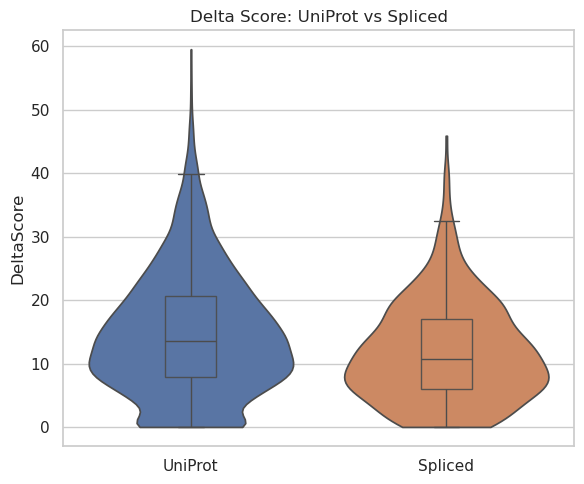

In [9]:
# Delta Score — violin + boxplot
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(
    data=cmp_df,
    x="Group",
    y="DeltaScore",
    hue="Group",
    order=GROUP_ORDER,
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    inner=None,
    cut=0,
    legend=False,
    ax=ax,
)
sns.boxplot(
    data=cmp_df,
    x="Group",
    y="DeltaScore",
    hue="Group",
    order=GROUP_ORDER,
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    width=0.2,
    fliersize=0,
    legend=False,
    boxprops={"zorder": 2, "alpha": 0.9},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("DeltaScore")
ax.set_title("Delta Score: UniProt vs Spliced")
plt.tight_layout()
plt.show()

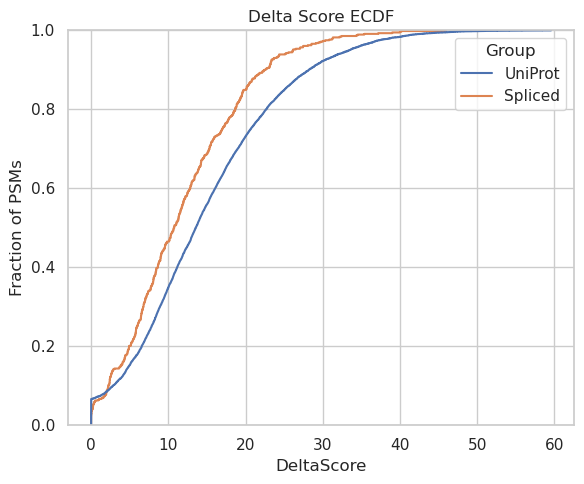

In [12]:
# Delta Score — ECDF
fig, ax = plt.subplots(figsize=(6, 5))
sns.ecdfplot(
    data=cmp_df,
    x="DeltaScore",
    hue="Group",
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    ax=ax,
)
ax.set_xlabel("DeltaScore")
ax.set_ylabel("Fraction of PSMs")
ax.set_title("Delta Score ECDF")
plt.tight_layout()
plt.show()

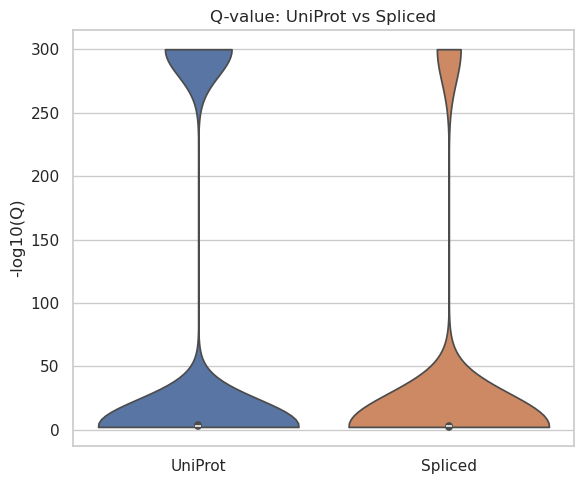

In [13]:
# Q-value — violin (-log10 Q)
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(
    data=cmp_df,
    x="Group",
    y="minuslog10_q",
    hue="Group",
    order=GROUP_ORDER,
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    cut=0,
    legend=False,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("-log10(Q)")
ax.set_title("Q-value: UniProt vs Spliced")
plt.tight_layout()
plt.show()

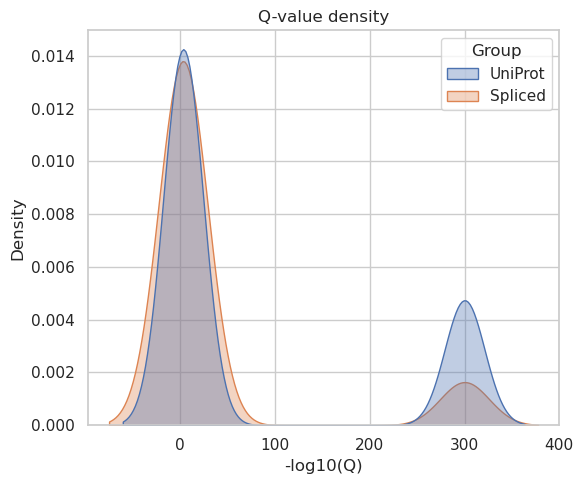

In [14]:
# Q-value — density
fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(
    data=cmp_df,
    x="minuslog10_q",
    hue="Group",
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    fill=True,
    alpha=0.35,
    common_norm=False,
    ax=ax,
)
ax.set_xlabel("-log10(Q)")
ax.set_ylabel("Density")
ax.set_title("Q-value density")
plt.tight_layout()
plt.show()

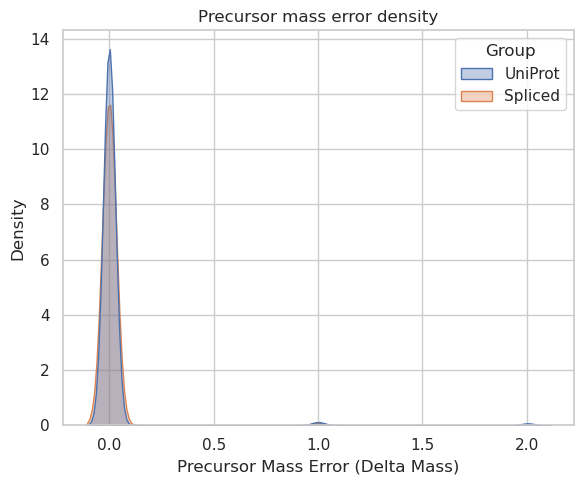

In [15]:
# Precursor mass error — density
fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(
    data=cmp_df,
    x="Delta Mass",
    hue="Group",
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    fill=True,
    alpha=0.35,
    common_norm=False,
    ax=ax,
)
ax.set_xlabel("Precursor Mass Error (Delta Mass)")
ax.set_ylabel("Density")
ax.set_title("Precursor mass error density")
plt.tight_layout()
plt.show()

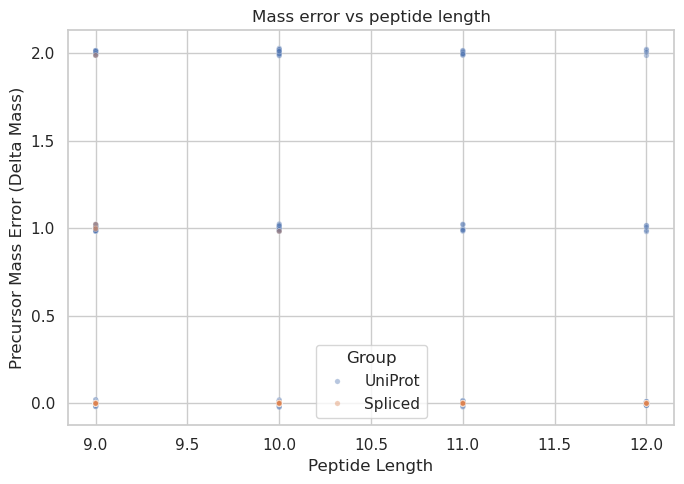

In [16]:
# Precursor mass error vs peptide length
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=cmp_df,
    x="Peptide Length",
    y="Delta Mass",
    hue="Group",
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    alpha=0.4,
    s=15,
    ax=ax,
)
ax.set_xlabel("Peptide Length")
ax.set_ylabel("Precursor Mass Error (Delta Mass)")
ax.set_title("Mass error vs peptide length")
plt.tight_layout()
plt.show()

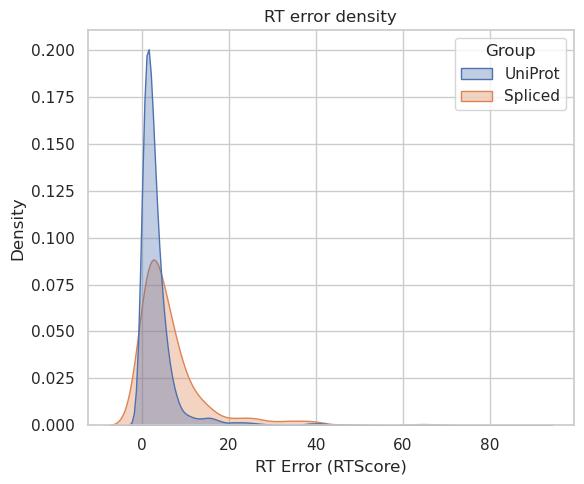

In [17]:
# RT error — density
fig, ax = plt.subplots(figsize=(6, 5))
sns.kdeplot(
    data=cmp_df,
    x="RTScore",
    hue="Group",
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    fill=True,
    alpha=0.35,
    common_norm=False,
    ax=ax,
)
ax.set_xlabel("RT Error (RTScore)")
ax.set_ylabel("Density")
ax.set_title("RT error density")
plt.tight_layout()
plt.show()

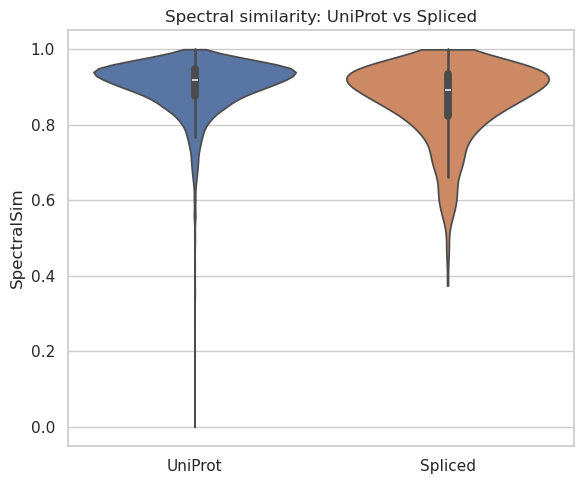

In [18]:
# Spectral similarity — violin
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(
    data=cmp_df,
    x="Group",
    y="SpectralSim",
    hue="Group",
    order=GROUP_ORDER,
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    cut=0,
    legend=False,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("SpectralSim")
ax.set_title("Spectral similarity: UniProt vs Spliced")
plt.tight_layout()
plt.show()

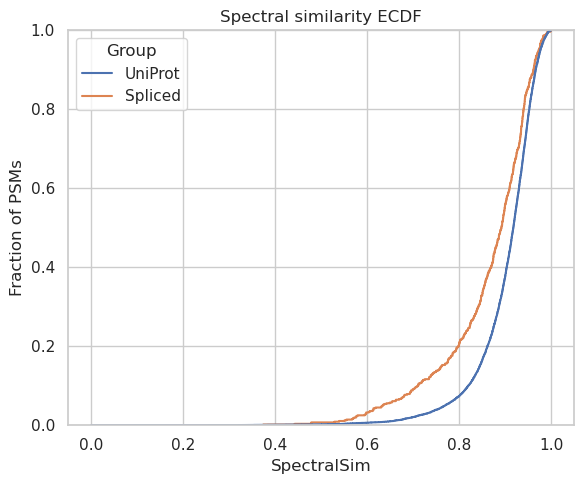

In [19]:
# Spectral similarity — ECDF
fig, ax = plt.subplots(figsize=(6, 5))
sns.ecdfplot(
    data=cmp_df,
    x="SpectralSim",
    hue="Group",
    hue_order=GROUP_ORDER,
    palette=PALETTE,
    ax=ax,
)
ax.set_xlabel("SpectralSim")
ax.set_ylabel("Fraction of PSMs")
ax.set_title("Spectral similarity ECDF")
plt.tight_layout()
plt.show()

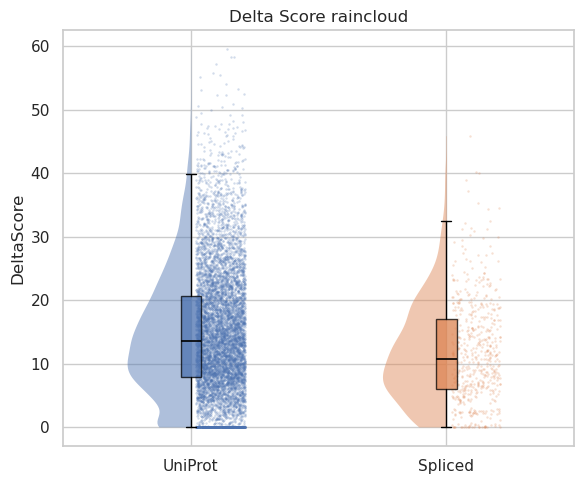

In [20]:
# Raincloud — DeltaScore
fig, ax = plt.subplots(figsize=(6, 5))
raincloud_plot(ax, cmp_df, y_col="DeltaScore")
ax.set_xlabel("")
ax.set_ylabel("DeltaScore")
ax.set_title("Delta Score raincloud")
plt.tight_layout()
plt.show()

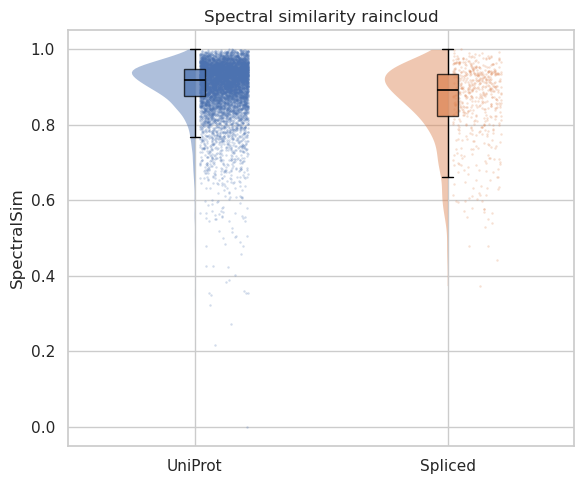

In [21]:
# Raincloud — SpectralSim
fig, ax = plt.subplots(figsize=(6, 5))
raincloud_plot(ax, cmp_df, y_col="SpectralSim")
ax.set_xlabel("")
ax.set_ylabel("SpectralSim")
ax.set_title("Spectral similarity raincloud")
plt.tight_layout()
plt.show()

In [10]:
# Non-parametric group comparisons
from scipy.stats import mannwhitneyu


def cliffs_delta(x, y):
    """Cliff's delta: positive => first group tends to be larger than second."""
    x = np.asarray(x)
    y = np.asarray(y)
    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan
    diff = x[:, None] - y[None, :]
    return (np.sum(diff > 0) - np.sum(diff < 0)) / (n1 * n2)


def iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    return q3 - q1


def compare_metric(data, col, label):
    uni = data.loc[data["Group"] == "UniProt", col].dropna()
    spli = data.loc[data["Group"] == "Spliced", col].dropna()

    _, p_value = mannwhitneyu(uni, spli, alternative="two-sided")

    return {
        "Metric": label,
        "UniProt median": uni.median(),
        "UniProt IQR": iqr(uni),
        "Spliced median": spli.median(),
        "Spliced IQR": iqr(spli),
        "Mann-Whitney p": p_value,
        "Cliff's delta": cliffs_delta(uni.values, spli.values),
    }


METRICS = [
    ("DeltaScore", "Delta Score"),
    ("minuslog10_q", "Q-value (-log10)"),
    ("Delta Mass", "Precursor Mass Error"),
    ("RTScore", "RT Error"),
    ("SpectralSim", "Spectral Similarity"),
]

stats_df = pd.DataFrame([compare_metric(cmp_df, col, label) for col, label in METRICS])
stats_df

,Metric,UniProt median,UniProt IQR,Spliced median,Spliced IQR,Mann-Whitney p,Cliff's delta
0,Delta Score,13.54900,12.85600,10.756000,10.976000,3.576022e-12,0.175526
1,Q-value (-log10),3.36135,0.81232,3.177789,0.704812,3.459529e-36,0.314266
2,Precursor Mass Error,-0.00070,0.00140,-0.000700,0.001400,8.654444e-01,0.004276
3,RT Error,2.04500,2.92630,3.935300,6.216600,6.879655e-33,-0.301590
4,Spectral Similarity,0.91750,0.07170,0.891500,0.111700,2.690443e-20,0.233053
